In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns

In [ ]:
# -- Data ----------------------------------------------------

CONTROL_POINTS = np.array([
    [1, 1],   # P0
    [3, 3],   # P1
    [5, 1],   # P2
])

U_SNAPSHOTS = [0.25, 0.50, 0.75]

# One color set per snapshot
SNAPSHOT_COLORS = ['#E91E63', '#FF6F00', '#6A1B9A']

In [ ]:
# -- De Casteljau Computation --------------------------------

class DeCasteljauQuadratic:
    """
    Quadratic Bezier via De Casteljau algorithm.
    Returns all intermediate points for visualization.

    Level 0 : P0, P1, P2  (control points)
    Level 1 : Q0 = lerp(P0,P1,u), Q1 = lerp(P1,P2,u)
    Level 2 : R0 = lerp(Q0,Q1,u)  <- curve point
    """

    def __init__(self, points: np.ndarray):
        self.p0 = points[0]
        self.p1 = points[1]
        self.p2 = points[2]

    def _lerp(
        self,
        a: np.ndarray,
        b: np.ndarray,
        u: float
    ) -> np.ndarray:
        """Linear interpolation between a and b at u."""
        return (1 - u) * a + u * b

    def steps(self, u: float) -> dict:
        """Return dict of all level points at u."""
        p0, p1, p2 = self.p0, self.p1, self.p2
        q0 = self._lerp(p0, p1, u)
        q1 = self._lerp(p1, p2, u)
        r0 = self._lerp(q0, q1, u)
        return {
            'level0': np.array([p0, p1, p2]),
            'level1': np.array([q0, q1]),
            'level2': np.array([r0]),
        }

    def point(self, u: float) -> np.ndarray:
        """Return final curve point at u."""
        return self.steps(u)['level2'][0]

    def curve(self, n: int = 200) -> np.ndarray:
        """Return smooth curve array."""
        u_vals = np.linspace(0, 1, n)
        return np.array([self.point(u) for u in u_vals])

In [ ]:
# -- Plot ----------------------------------------------------

class DeCasteljauPlot:
    """
    Single-figure De Casteljau visualization.
    All u-snapshots overlaid on one chart.
    """

    COLOR_CURVE   = '#1565C0'
    COLOR_POLYGON = '#424242'

    CTRL_NAMES  = ['P0(1,1)', 'P1(3,3)', 'P2(5,1)']
    CTRL_OFFSET = [(-0.30, -0.20),
                   ( 0.07,  0.08),
                   ( 0.10, -0.20)]

    def __init__(
        self,
        bezier: DeCasteljauQuadratic,
        u_snapshots: list,
        colors: list
    ):
        self.bezier      = bezier
        self.u_snapshots = u_snapshots
        self.colors      = colors
        self.fig, self.ax = self._init_figure()

    def _init_figure(self):
        """Initialize single figure with seaborn style."""
        sns.set_theme(style='whitegrid')
        fig, ax = plt.subplots(figsize=(8, 6))
        return fig, ax

    # -- Static elements -------------------------------------

    def _draw_curve(self):
        """Draw the full smooth Bezier curve."""
        pts = self.bezier.curve()
        self.ax.plot(
            pts[:, 0], pts[:, 1],
            color=self.COLOR_CURVE,
            linewidth=2.5,
            label='Bezier Curve',
            zorder=2
        )

    def _draw_control_polygon(self):
        """Draw dashed control polygon P0-P1-P2."""
        pts = self.bezier.steps(0)['level0']
        self.ax.plot(
            pts[:, 0], pts[:, 1],
            color=self.COLOR_POLYGON,
            linestyle='--',
            linewidth=1.4,
            marker='o',
            markersize=7,
            zorder=3,
            label='Control Polygon'
        )

    def _label_control_points(self):
        """Label P0, P1, P2 next to each control point."""
        pts = self.bezier.steps(0)['level0']
        for pt, name, (dx, dy) in zip(
            pts, self.CTRL_NAMES, self.CTRL_OFFSET
        ):
            self.ax.text(
                pt[0] + dx, pt[1] + dy,
                name,
                fontsize=8.5,
                color=self.COLOR_POLYGON,
                fontweight='bold'
            )

    # -- Per-snapshot elements -------------------------------

    def _draw_snapshot(self, u: float, color: str):
        """Draw level-1 segment and level-2 point for u."""
        data = self.bezier.steps(u)
        l1   = data['level1']
        r0   = data['level2'][0]

        # Level 1: Q0-Q1 segment
        self.ax.plot(
            l1[:, 0], l1[:, 1],
            color=color,
            linewidth=1.6,
            zorder=4
        )

        # Level 1: Q0, Q1 dots
        self.ax.scatter(
            l1[:, 0], l1[:, 1],
            color=color,
            s=40, zorder=5
        )

        # Level 2: R0 curve point (diamond marker)
        self.ax.scatter(
            r0[0], r0[1],
            color=color,
            s=80,
            marker='D',
            zorder=6
        )

    def _label_snapshot(self, u: float, color: str):
        """Label Q0, Q1 and R0 for one snapshot."""
        data     = self.bezier.steps(u)
        l1       = data['level1']
        r0       = data['level2'][0]
        q_offset = [(-0.35, 0.05), (0.08, 0.05)]

        for pt, name, (dx, dy) in zip(
            l1, ['Q0', 'Q1'], q_offset
        ):
            self.ax.text(
                pt[0] + dx, pt[1] + dy,
                f'{name}({u:.2f})',
                fontsize=7,
                color=color
            )

        self.ax.text(
            r0[0] + 0.08, r0[1] - 0.22,
            f'R0({u:.2f})\n'
            f'({r0[0]:.2f},{r0[1]:.2f})',
            fontsize=7,
            color=color,
            fontweight='bold'
        )

    # -- Legend ----------------------------------------------

    def _make_legend(self):
        """Build and attach the figure legend."""
        handles = [
            mlines.Line2D(
                [], [],
                color=self.COLOR_CURVE,
                linewidth=2.5,
                label='Bezier Curve'
            ),
            mlines.Line2D(
                [], [],
                color=self.COLOR_POLYGON,
                linestyle='--',
                marker='o',
                markersize=6,
                label='Control Polygon'
            ),
        ]
        for u, color in zip(
            self.u_snapshots, self.colors
        ):
            handles.append(mlines.Line2D(
                [], [],
                color=color,
                linewidth=1.6,
                marker='D',
                markersize=5,
                label=f'De Casteljau u={u:.2f}'
            ))
        self.ax.legend(
            handles=handles,
            fontsize=8.5,
            loc='upper right'
        )

    # -- Decoration ------------------------------------------

    def _set_decorations(self):
        """Set title, axis labels and limits."""
        self.ax.set_title(
            'De Casteljau Algorithm — Quadratic Bezier',
            fontsize=13,
            fontweight='bold',
            pad=14
        )
        self.ax.set_xlabel('x', fontsize=11)
        self.ax.set_ylabel('y', fontsize=11)
        self.ax.set_xlim(0.4, 5.8)
        self.ax.set_ylim(0.4, 3.6)
        self.ax.set_aspect('equal')

    # -- Main ------------------------------------------------

    def draw(self):
        """Compose all elements onto the single chart."""
        self._draw_curve()
        self._draw_control_polygon()
        self._label_control_points()

        for u, color in zip(
            self.u_snapshots, self.colors
        ):
            self._draw_snapshot(u, color)
            self._label_snapshot(u, color)

        self._make_legend()
        self._set_decorations()

    def save(self, filename: str):
        """Save figure to file (relative path)."""
        self.fig.tight_layout()
        self.fig.savefig(filename, dpi=150)
        print(f'Saved: {filename}')

    def show(self):
        """Display the figure."""
        self.fig.tight_layout()
        plt.show()


In [ ]:
# -- Entry Point ---------------------------------------------

def main() -> int:
    bezier = DeCasteljauQuadratic(CONTROL_POINTS)
    plot   = DeCasteljauPlot(
        bezier, U_SNAPSHOTS, SNAPSHOT_COLORS
    )
    plot.draw()
    plot.save('12-bezier_decasteljau.png')
    plot.show()
    return 0

Saved: 12-bezier_decasteljau.png


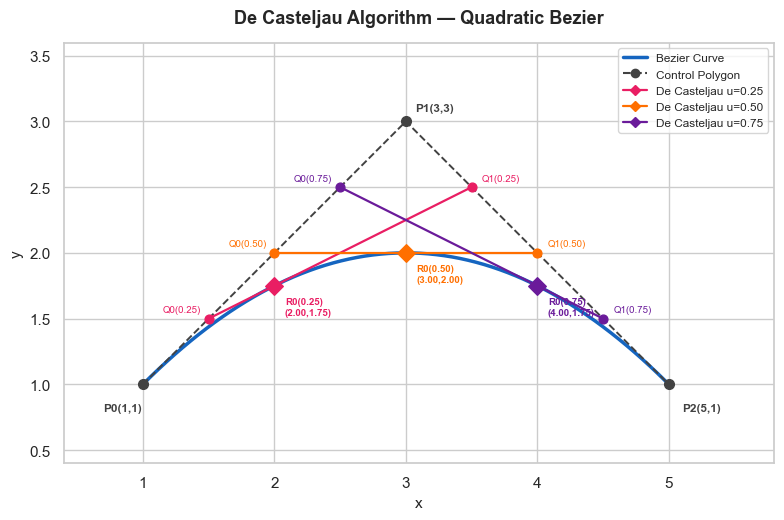

0

In [11]:
main()